# FLSTM Gates Only using SG
Dataset: Sunspots

**Classification Metrics Evaluation (No Noise)**

In [1]:
# ============================================================
# PROCESS IDENTIFICATION
# ============================================================
import os
print(f"Process ID (PID): {os.getpid()}")


Process ID (PID): 6013


In [2]:
# ============================================================
# NOTEBOOK TIMER — START
# ============================================================
import time as _timer_module
_NOTEBOOK_START_TIME = _timer_module.time()
print(f"Notebook execution started at: {_timer_module.strftime('%Y-%m-%d %H:%M:%S')}")


Notebook execution started at: 2026-07-20 10:50:02


In [3]:
# ============================================================
# CPU ONLY Settings (Forced)
# ============================================================
import tensorflow as tf
import platform

try:
    tf.config.set_visible_devices([], 'GPU')
    print('Forcing CPU execution (disabled GPU visibility).')
except RuntimeError as e:
    print(e)


Forcing CPU execution (disabled GPU visibility).


In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt





In [5]:
# ============================================================
# Wang-Mendel Fuzzy Rule Base with Triangular MFs
# (FLSTM paper: doi:10.1038/s41598-023-47812-3)
# ============================================================
Q_REGIONS = 5

def triangular_mf_np(x, a, b, c):
    """Triangular membership function: vertices at (a, 0), (b, 1), (c, 0)."""
    return np.maximum(0.0, np.minimum((x - a) / (b - a + 1e-10),
                                      (c - x) / (c - b + 1e-10)))

def build_triangular_fuzzy_sets(data_min, data_max, q=Q_REGIONS):
    """Build q equally-spaced triangular fuzzy sets over [data_min, data_max]."""
    centers = np.linspace(data_min, data_max, q)
    step = centers[1] - centers[0] if q > 1 else 1.0
    fuzzy_sets = []
    for center in centers:
        fuzzy_sets.append((center - step, center, center + step))
    return fuzzy_sets, centers

def fuzzify_value(value, fuzzy_sets):
    """Return (best_set_index, membership_degree) for a single value."""
    best_idx, best_mu = 0, 0.0
    for i, (a, b, c) in enumerate(fuzzy_sets):
        mu = triangular_mf_np(value, a, b, c)
        if mu > best_mu:
            best_mu = mu
            best_idx = i
    return best_idx, max(best_mu, 1e-10)

def extract_wm_rules(X, y, fs_x_list, fs_y):
    """Extract fuzzy rules using the Wang-Mendel method.
    X: (N, n_features), y: (N,)
    fs_x_list: list of fuzzy_sets (one per feature)
    fs_y: fuzzy_sets for output
    Returns dict: tuple(antecedent_indices) -> (consequent_index, weight)
    """
    rules = {}
    n_features = X.shape[1]
    for i in range(len(X)):
        antecedents = []
        weight = 1.0
        for j in range(n_features):
            idx, mu = fuzzify_value(X[i, j], fs_x_list[j])
            antecedents.append(idx)
            weight *= mu
        cons_idx, cons_mu = fuzzify_value(y[i], fs_y)
        weight *= cons_mu
        key = tuple(antecedents)
        if key not in rules or weight > rules[key][1]:
            rules[key] = (cons_idx, weight)
    return rules

def complement_wm_rules(rules, q, n_features, centers_y):
    """Add complement rules for missing antecedent combinations.
    For each missing combination, assign the consequent of the nearest existing rule.
    """
    import itertools
    all_combos = list(itertools.product(range(q), repeat=n_features))
    for combo in all_combos:
        if combo not in rules:
            best_dist = float('inf')
            best_cons = q // 2
            for existing_key, (cons, w) in rules.items():
                dist = sum((a - b) ** 2 for a, b in zip(combo, existing_key))
                if dist < best_dist:
                    best_dist = dist
                    best_cons = cons
            rules[combo] = (best_cons, 0.1)
    return rules

def wm_fuzzy_predict(x_features, rules, fs_x_list, centers_y, q=Q_REGIONS):
    """Predict using fuzzy rule base with center-average defuzzification.
    x_features: 1D array of input features for one sample.
    """
    n_features = len(x_features)
    # Compute membership degrees for each feature across all q regions
    memberships = []
    for j in range(n_features):
        mf_vals = []
        for k in range(q):
            a, b, c = fs_x_list[j][k]
            mf_vals.append(triangular_mf_np(x_features[j], a, b, c))
        memberships.append(mf_vals)
    # Weighted average defuzzification over all rules
    total_weight = 0.0
    weighted_sum = 0.0
    for antecedents, (consequent, _) in rules.items():
        strength = 1.0
        for j, ant_idx in enumerate(antecedents):
            strength *= memberships[j][ant_idx]
        if strength > 1e-10:
            weighted_sum += strength * centers_y[consequent]
            total_weight += strength
    if total_weight > 1e-10:
        return weighted_sum / total_weight
    return 0.0

def build_wm_system(X_train, y_train, q=Q_REGIONS):
    """Build complete Wang-Mendel fuzzy system from training data.
    Returns: (rules, fs_x_list, centers_y)
    """
    n_features = X_train.shape[1]
    fs_x_list = []
    for j in range(n_features):
        col = X_train[:, j]
        fs, _ = build_triangular_fuzzy_sets(col.min(), col.max(), q)
        fs_x_list.append(fs)
    fs_y, centers_y = build_triangular_fuzzy_sets(y_train.min(), y_train.max(), q)
    rules = extract_wm_rules(X_train, y_train, fs_x_list, fs_y)
    rules = complement_wm_rules(rules, q, n_features, centers_y)
    return rules, fs_x_list, centers_y

def compute_fuzzy_predictions(X, rules, fs_x_list, centers_y, q=Q_REGIONS):
    """Compute Wang-Mendel fuzzy predictions for an array of samples."""
    preds = np.zeros(len(X))
    for i in range(len(X)):
        preds[i] = wm_fuzzy_predict(X[i], rules, fs_x_list, centers_y, q)
    return preds


In [6]:
# ============================================================
# Membership Functions
# ============================================================
def dog(x, mu1=-1.0, mu2=1.0, sigma1=0.5, sigma2=0.5):
    return tf.exp(-tf.square(x - mu1)/ (2 * sigma1**2)) - tf.exp(-tf.square(x - mu2)/ (2 * sigma2**2))

def signed_gaussian(x, sigma=0.5):
    return x * tf.exp(-tf.square(x)/ (2 * sigma**2))

def generalized_bell(x, a=1.0, b=2.0, c_val=0.0):
    return 1.0 / (1.0 + tf.pow(tf.abs((x - c_val) / a), 2*b))

# ============================================================
# FLSTM Cell: MF-based gates + Fuzzy Prediction Fusion
# (r_t is integrated into gate computations via separate weights)
# ============================================================
@tf.keras.utils.register_keras_serializable()
class MembershipFLSTMSNPCell(layers.Layer):
    def __init__(self, units, mf_type='sg', **kwargs):
        super().__init__(**kwargs)
        self.units, self.mf_type = units, mf_type
        self.state_size, self.output_size = (units, units, units), units
        self.mf = dog if mf_type == 'dog' else signed_gaussian if mf_type == 'sg' else generalized_bell

    def build(self, input_shape):
        # input_shape[-1] includes the fuzzy prediction r_t as the LAST feature
        total_input_dim = input_shape[-1]
        actual_input_dim = total_input_dim - 1  # exclude r_t
        self.kernel = self.add_weight(shape=(actual_input_dim, self.units * 4), initializer='glorot_uniform', name='kernel')
        self.recurrent_kernel = self.add_weight(shape=(self.units, self.units * 4), initializer='orthogonal', name='recurrent_kernel')
        self.bias = self.add_weight(shape=(self.units * 4,), initializer='zeros', name='bias')
        # Fuzzy prediction fusion weights: W_gf, W_gi, W_go (Eq. 14-16)
        # r_t is scalar → separate weight for each of 3 gates (not candidate)
        self.fuzzy_gate_kernel = self.add_weight(shape=(1, self.units * 3), initializer='glorot_uniform', name='fuzzy_gate_kernel')

    def call(self, inputs, states):
        u_tm1 = states[0]
        # Split: actual input features vs fuzzy prediction r_t
        x_t = inputs[:, :-1]
        r_t = inputs[:, -1:]  # (batch, 1)
        z = tf.matmul(x_t, self.kernel) + tf.matmul(u_tm1, self.recurrent_kernel) + self.bias
        z0, z1, z2, z3 = z[:, :self.units], z[:, self.units:2*self.units], z[:, 2*self.units:3*self.units], z[:, 3*self.units:]
        # Add fuzzy prediction contribution to gates (Eq. 14-16)
        fz = tf.matmul(r_t, self.fuzzy_gate_kernel)
        z0 = z0 + fz[:, :self.units]
        z1 = z1 + fz[:, self.units:2*self.units]
        z2 = z2 + fz[:, 2*self.units:]

        r = tf.tanh(z0)
        c = tf.clip_by_value(self.mf(z1), -1.0, 1.0)
        o = tf.clip_by_value(self.mf(z2), -1.0, 1.0)
        a = tf.tanh(z3)

        u = r * u_tm1 - c * a
        h = o * a
        return h, [u, c, o]

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units, 'mf_type': self.mf_type})
        return config

# ============================================================
# Strengthening Memory Layer (Eq. 17-19)
# ============================================================
@tf.keras.utils.register_keras_serializable()
class StrengtheningMemoryLayer(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units_out = units
        self.dense = layers.Dense(units, activation='tanh')

    def call(self, inputs):
        h_t, c_t = inputs
        ch_t = h_t + c_t       # Eq. 17
        s_t = self.dense(ch_t)  # Eq. 18 (Conv1d on single vector ≈ Dense)
        h_hat = ch_t + s_t      # Eq. 19
        return h_hat

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units_out})
        return config


In [7]:
def build_model(input_dim, units, batch_size):
    cell = MembershipFLSTMSNPCell(units, mf_type='sg')
    rnn = layers.RNN(cell, return_sequences=False, return_state=True, stateful=True)

    # input_dim already includes r_t as last feature
    inputs = tf.keras.Input(batch_shape=(batch_size, 1, input_dim))
    x, u_out, c_out, o_out = rnn(inputs)
    # Strengthening Memory Layer
    h_strengthened = StrengtheningMemoryLayer(units)([x, u_out])
    outputs = layers.Dense(1)(h_strengthened)

    model = tf.keras.Model(inputs=inputs, outputs=[outputs, c_out, o_out])
    model.compile(optimizer=tf.keras.optimizers.legacy.Adam(clipnorm=1.0), loss=['mean_squared_error', None, None])
    return model



EVALUATING: Gates Only (SG) on Sunspots — Normal Condition (No Noise)


===== RUN 1/2 =====


Run 1 — Acc: 60.0%, Spec: 24.1%, Prec: 56.9%, Recall: 93.5%, AUC: 68.9%

===== RUN 2/2 =====


Run 2 — Acc: 58.3%, Spec: 24.1%, Prec: 56.0%, Recall: 90.3%, AUC: 56.3%

===== FINAL RESULTS — Gates Only (SG) on Sunspots (2 runs) =====
Accuracy:    59.2%
Specificity: 24.1%
Precision:   56.4%
Recall:      91.9%
AUC:         62.6%


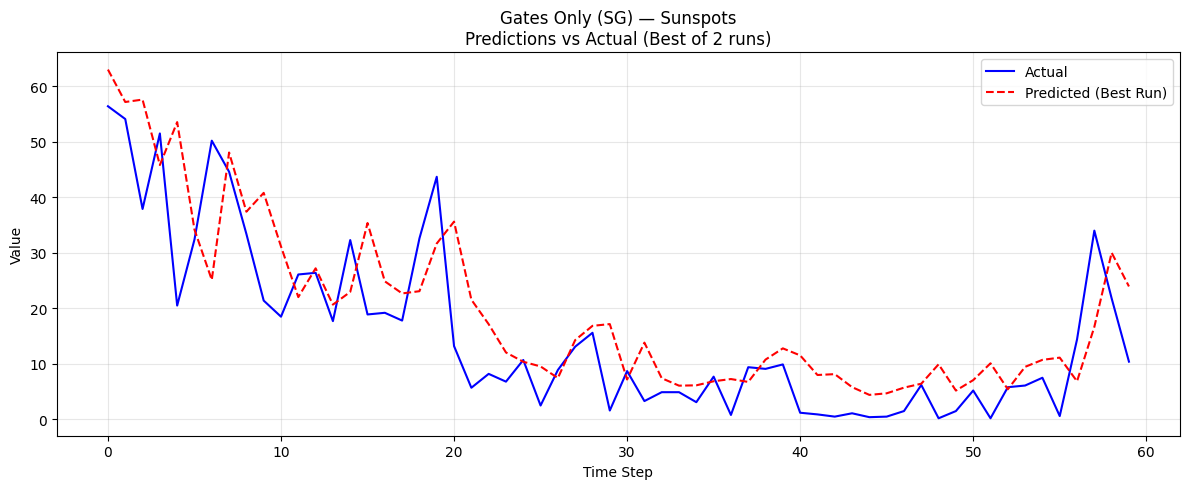

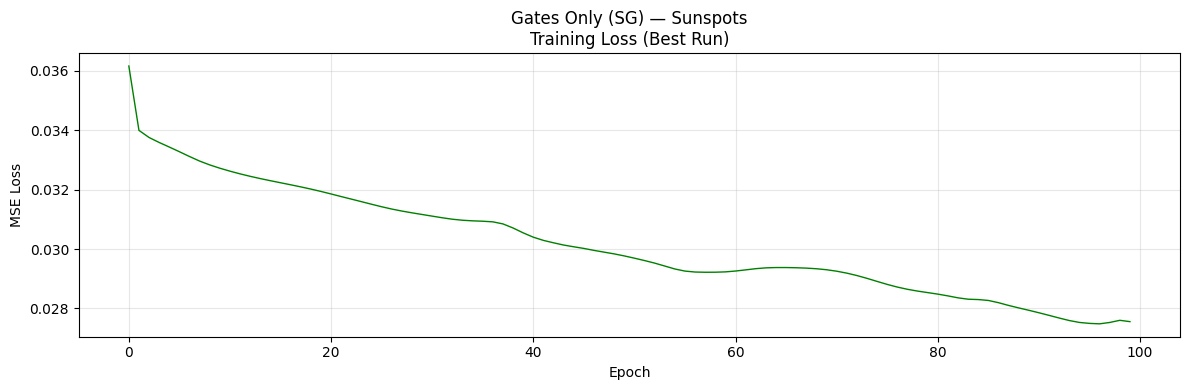

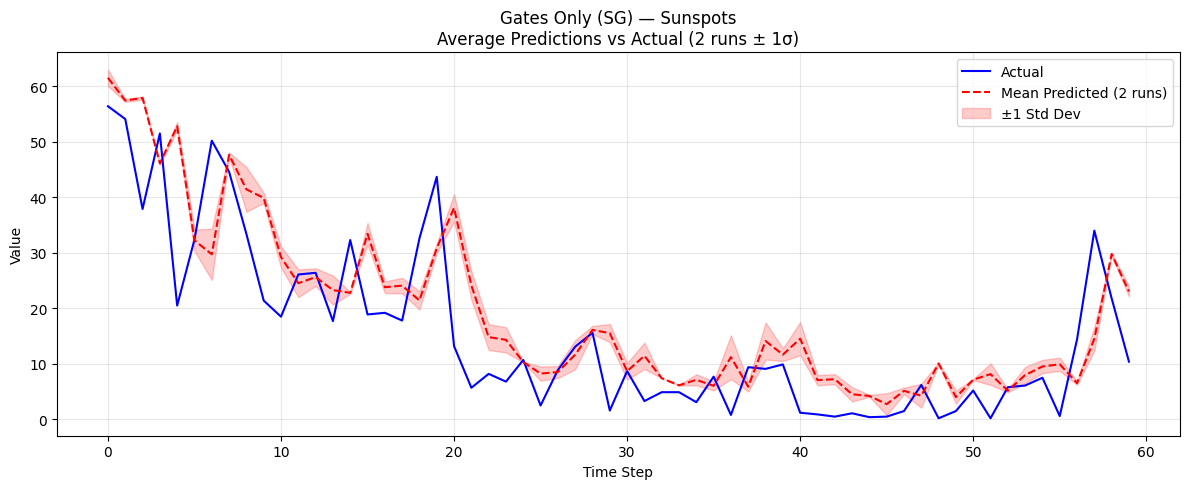


╔═════════════════════════════════════════════════════════════════════════════════════╗
║ CLASSIFICATION RESULTS — Gates Only (SG) on Sunspots (2 runs)                       ║
╠═══════════════╦═══════════════╦═══════════════╦═══════════════╦══════════════════╣
║ Accuracy      ║ Specificity   ║ Precision     ║ Recall        ║ AUC              ║
╠═══════════════╬═══════════════╬═══════════════╬═══════════════╬══════════════════╣
║ 59.2%         ║ 24.1%         ║ 56.4%         ║ 91.9%         ║ 62.6%            ║
╚═══════════════╩═══════════════╩═══════════════╩═══════════════╩══════════════════╝


In [8]:
series = pd.read_csv('../content/Sunspots.csv')
raw_values = series['Monthly Mean Total Sunspot Number'].values.flatten()
import numpy as np
original_raw_values = np.copy(raw_values)

# Classification metrics imports
from sklearn.metrics import precision_score, recall_score, roc_auc_score

def difference(dataset, interval=1):
    diff = []
    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)
    return np.array(diff)

def timeseries_to_supervised(data, lag):
    df = pd.DataFrame(data)
    columns = [df.shift(i) for i in range(1, lag+1)]
    columns.append(df)
    df = pd.concat(columns, axis=1)
    df.fillna(0, inplace=True)
    return df.values

diff_values = difference(raw_values, 1)
supervised = timeseries_to_supervised(diff_values, 5)
train, test = supervised[:-60], supervised[-60:]
scaler = MinMaxScaler(feature_range=(-1, 1))
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

X_train_raw, y_train = train_scaled[:, 0:-1], train_scaled[:, -1]
X_test_raw, y_test = test_scaled[:, 0:-1], test_scaled[:, -1]

# Build WM fuzzy system from training data
wm_rules, wm_fs_x, wm_centers_y = build_wm_system(X_train_raw, y_train)

# Compute WM fuzzy predictions r_t for gate fusion
r_train = compute_fuzzy_predictions(X_train_raw, wm_rules, wm_fs_x, wm_centers_y)
r_test = compute_fuzzy_predictions(X_test_raw, wm_rules, wm_fs_x, wm_centers_y)

# Concatenate r_t as last feature: [x_t, r_t]
X_train_aug = np.column_stack([X_train_raw, r_train])
X_test_aug = np.column_stack([X_test_raw, r_test])

X_train = X_train_aug.reshape((X_train_aug.shape[0], 1, X_train_aug.shape[1]))
X_test = X_test_aug.reshape((X_test_aug.shape[0], 1, X_test_aug.shape[1]))

# ============================================================
# TRAINING & EVALUATION (2 runs, No Noise)
# ============================================================
print('\n' + '='*80)
print('EVALUATING: Gates Only (SG) on Sunspots — Normal Condition (No Noise)')
print('='*80 + '\n')

all_rmse, all_mae, all_predictions, all_losses = [], [], [], []
all_c_means, all_c_stds, all_c_mins, all_c_maxs = [], [], [], []
all_o_means, all_o_stds, all_o_mins, all_o_maxs = [], [], [], []
all_accuracy, all_specificity, all_precision, all_recall, all_auc = [], [], [], [], []

for run in range(2):
    print(f'\n===== RUN {run+1}/2 =====')
    np.random.seed(run)
    tf.random.set_seed(run)
    tf.keras.backend.clear_session()

    model = build_model(input_dim=6, units=8, batch_size=1)
    rnn_layer = model.layers[1]

    run_losses = []
    for epoch in range(100):
        history = model.fit(X_train, y_train, epochs=1, batch_size=1, verbose=0, shuffle=False)
        run_losses.append(history.history['loss'][0])
        rnn_layer.reset_states()
    all_losses.append(run_losses)

    # Warmup
    for i in range(len(X_train)): model.predict(X_train[i:i+1], batch_size=1, verbose=0)

    predictions, c_gates, o_gates = [], [], []
    for i in range(len(X_test)):
        yhat, c_val, o_val = model.predict(X_test[i:i+1], batch_size=1, verbose=0)
        c_gates.append(c_val[0])
        o_gates.append(o_val[0])

        row = list(X_test_raw[i]) + [yhat[0, 0]]
        inv = scaler.inverse_transform([row])[0, -1] + raw_values[len(train) + i]
        predictions.append(inv)

    c_gates, o_gates = np.array(c_gates), np.array(o_gates)
    all_c_means.append(np.mean(c_gates)); all_c_stds.append(np.std(c_gates))
    all_c_mins.append(np.min(c_gates)); all_c_maxs.append(np.max(c_gates))
    all_o_means.append(np.mean(o_gates)); all_o_stds.append(np.std(o_gates))
    all_o_mins.append(np.min(o_gates)); all_o_maxs.append(np.max(o_gates))

    actual = raw_values[-60:]
    rmse = sqrt(mean_squared_error(actual, predictions))
    mae = np.mean(np.abs(np.array(actual) - np.array(predictions)))

    all_rmse.append(rmse)
    all_mae.append(mae)
    all_predictions.append(predictions)

    # ---- Classification Metrics (Dynamic Threshold: Median) ----
    train_raw_values = raw_values[:-60]
    train_diffs = np.diff(train_raw_values)
    tau = round(float(np.median(train_diffs)), 6)
    
    y_prev = raw_values[-(len(actual)+1):-1]
    true_dir = ((np.array(actual) - y_prev) > tau).astype(int)
    pred_dir = ((np.array(predictions) - y_prev) > tau).astype(int)
    pred_scores = (np.array(predictions) - y_prev) - tau  # confidence score for AUC

    TP = np.sum((true_dir == 1) & (pred_dir == 1))
    TN = np.sum((true_dir == 0) & (pred_dir == 0))
    FP = np.sum((true_dir == 0) & (pred_dir == 1))
    FN = np.sum((true_dir == 1) & (pred_dir == 0))

    accuracy = (TP + TN) / len(true_dir) if len(true_dir) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    try:
        auc = roc_auc_score(true_dir, pred_scores)
    except ValueError:
        auc = 0.5

    all_accuracy.append(accuracy)
    all_specificity.append(specificity)
    all_precision.append(precision)
    all_recall.append(recall)
    all_auc.append(auc)

    print(f'Run {run+1} — Acc: {accuracy*100:.1f}%, Spec: {specificity*100:.1f}%, Prec: {precision*100:.1f}%, Recall: {recall*100:.1f}%, AUC: {auc*100:.1f}%')

# ============================================================
# FINAL SUMMARY
# ============================================================
mean_accuracy = np.mean(all_accuracy) * 100
mean_specificity = np.mean(all_specificity) * 100
mean_precision = np.mean(all_precision) * 100
mean_recall = np.mean(all_recall) * 100
mean_auc = np.mean(all_auc) * 100

print('\n===== FINAL RESULTS — Gates Only (SG) on Sunspots (2 runs) =====')
print(f'Accuracy:    {mean_accuracy:.1f}%')
print(f'Specificity: {mean_specificity:.1f}%')
print(f'Precision:   {mean_precision:.1f}%')
print(f'Recall:      {mean_recall:.1f}%')
print(f'AUC:         {mean_auc:.1f}%')
# ---- Plots ----
best_idx = np.argmin(all_rmse)
actual = raw_values[-60:]
best_predictions = all_predictions[best_idx]

plt.figure(figsize=(12, 5))
plt.plot(actual, label='Actual', color='blue', linewidth=1.5)
plt.plot(best_predictions, label='Predicted (Best Run)', color='red', linewidth=1.5, linestyle='--')
plt.title('Gates Only (SG) — Sunspots\nPredictions vs Actual (Best of 2 runs)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(all_losses[best_idx], color='green', linewidth=1.0)
plt.title('Gates Only (SG) — Sunspots\nTraining Loss (Best Run)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

avg_predictions = np.mean(all_predictions, axis=0)
std_predictions = np.std(all_predictions, axis=0)

plt.figure(figsize=(12, 5))
plt.plot(actual, label='Actual', color='blue', linewidth=1.5)
plt.plot(avg_predictions, label='Mean Predicted (2 runs)', color='red', linewidth=1.5, linestyle='--')
plt.fill_between(range(len(actual)), avg_predictions - std_predictions, avg_predictions + std_predictions,
                 alpha=0.2, color='red', label='±1 Std Dev')
plt.title('Gates Only (SG) — Sunspots\nAverage Predictions vs Actual (2 runs ± 1σ)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# COMBINED CLASSIFICATION SUMMARY TABLE
# ============================================================
print('\n' + '╔' + '═'*85 + '╗')
print('║ CLASSIFICATION RESULTS — Gates Only (SG) on Sunspots (2 runs) '.ljust(86) + '║')
print('╠' + '═'*15 + '╦' + '═'*15 + '╦' + '═'*15 + '╦' + '═'*15 + '╦' + '═'*18 + '╣')
print('║ Accuracy      ║ Specificity   ║ Precision     ║ Recall        ║ AUC              ║')
print('╠' + '═'*15 + '╬' + '═'*15 + '╬' + '═'*15 + '╬' + '═'*15 + '╬' + '═'*18 + '╣')
acc_str = f'{mean_accuracy:.1f}%'
spec_str = f'{mean_specificity:.1f}%'
prec_str = f'{mean_precision:.1f}%'
rec_str = f'{mean_recall:.1f}%'
auc_str = f'{mean_auc:.1f}%'
print(f'║ {acc_str:<13} ║ {spec_str:<13} ║ {prec_str:<13} ║ {rec_str:<13} ║ {auc_str:<16} ║')
print('╚' + '═'*15 + '╩' + '═'*15 + '╩' + '═'*15 + '╩' + '═'*15 + '╩' + '═'*18 + '╝')


## Results

## Observations

### Gates Only (SG) on Sunspots

**Run the notebook to generate results.**


In [9]:
# ============================================================
# NOTEBOOK TIMER — END
# ============================================================
import time as _timer_module
_NOTEBOOK_END_TIME = _timer_module.time()
_NOTEBOOK_ELAPSED = _NOTEBOOK_END_TIME - _NOTEBOOK_START_TIME
_hours, _rem = divmod(_NOTEBOOK_ELAPSED, 3600)
_minutes, _seconds = divmod(_rem, 60)
print(f"\nTotal notebook execution time: {int(_hours)}h {int(_minutes)}m {_seconds:.2f}s")
print(f"Total seconds: {_NOTEBOOK_ELAPSED:.2f}")



Total notebook execution time: 0h 14m 24.89s
Total seconds: 864.89
